# Left ventricle fibers

Generate myocardial fiber directions on a voxelized left ventricle using Laplace fields to define local anatomical axes. This tutorial adapts the rule-based approach of [Bayer et al. (2012), *A Novel Rule-Based Algorithm for Assigning Myocardial Fiber Orientation to Computational Heart Models*](https://doi.org/10.1007/s10439-012-0593-5) to a finite-difference grid.

The workflow constructs a longitudinal field from apex to base and a transmural field across the wall. Their gradients define a local coordinate system, which is then used to assign a smoothly varying fiber angle at each tissue voxel.

## Load and display the ventricular geometry.

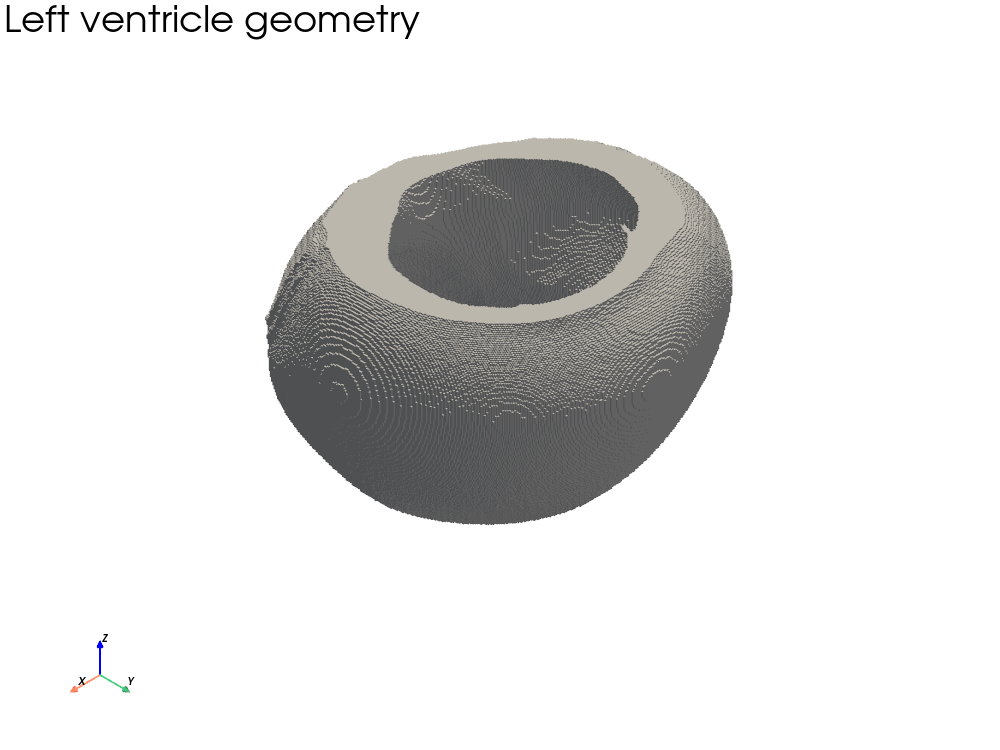

In [32]:
from pathlib import Path
import numpy as np
import pyvista as pv
import finitewave as fw


path = Path("./data")
mesh = np.load(path / "lv_mesh.npy")

grid = fw.PyVistaMeshGrid(mesh)

pv.set_jupyter_backend("static")
pl = pv.Plotter(window_size=(1000, 750))
pl.set_background("white")
pl.add_text("Left ventricle geometry", font_size=16, color="black")
pl.add_mesh(grid, color="lightgray", opacity=1.)
pl.view_isometric()
pl.enable_parallel_projection()
pl.show_axes()
pl.reset_camera()
pl.show()

## Extend the grid

Add one voxel layer around the tissue to support gradient calculation near its boundary.

The added layer supplies boundary nodes for the Laplace problems. The original tissue mask is retained so that gradients and fibers are evaluated only in the myocardium. The input tissue must not touch the edge of the volume.

In [33]:
from scipy import ndimage


def extract_surface(mesh):
    """Return the added surface layer and the dilated tissue mask.

    Parameters
    ----------
    mesh : ndarray, shape (nx, ny, nz)
        Voxel array with positive tissue values and zero background.

    Returns
    -------
    surface, dilated_mesh : ndarray of bool
        Added voxels and expanded tissue, both with the input shape.

    Raises
    ------
    ValueError
        If tissue touches any boundary of the input volume.
    """
    # check if mesh is touched by the boundary of the volume
    if (np.any([mesh[i, :, :].any() for i in [0, -1]])
        or np.any([mesh[:, i, :].any() for i in [0, -1]])
        or np.any([mesh[:, :, i].any() for i in [0, -1]])):
        raise ValueError("Mesh touches the boundary of the volume. "
                         "Cannot dilate mesh to create outer surface.")

    dilated_mesh = ndimage.binary_dilation(mesh > 0)
    surface = dilated_mesh & (mesh == 0)
    return surface, dilated_mesh


surface, dilated_mesh = extract_surface(mesh)
full_coords = np.argwhere(dilated_mesh > 0)
full_indices = np.flatnonzero(dilated_mesh > 0)
index_map = - np.ones_like(dilated_mesh, dtype=np.int32)
index_map[dilated_mesh > 0] = np.arange(full_indices.size, dtype=np.int32)

## Identify boundaries

Select the apex, base, endocardium, and epicardium. The apex location and surface labels below are specific to this mesh.

The apex is selected within a small radius of a chosen point, and the base is the plane at the largest z index. After removing the base from the added surface layer, connected-component labeling separates the inner and outer surfaces. Check the plots before reusing these selections with another geometry.

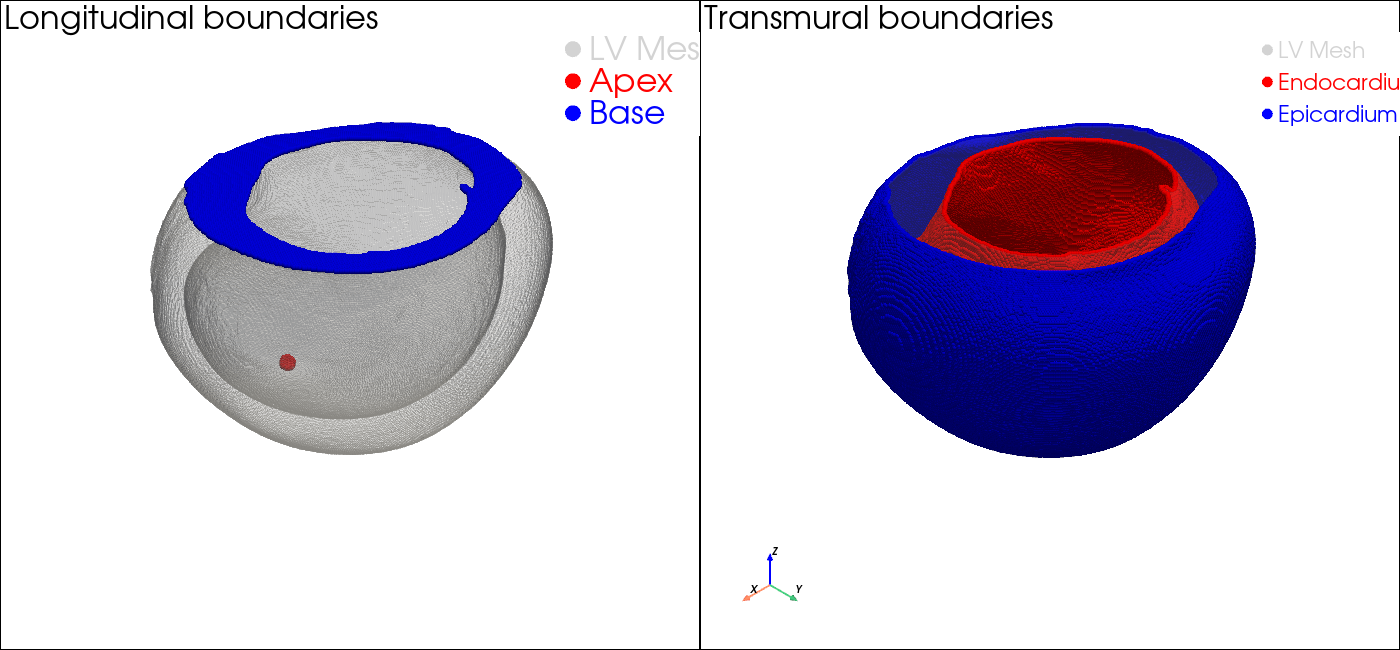

In [37]:
from scipy import ndimage, spatial


def extract_endo_epi_indices(surface, index_map):
    """Map the two surface components to endocardial and epicardial nodes.

    Parameters
    ----------
    surface : ndarray, shape (nx, ny, nz)
        Added surface mask with the base removed.
    index_map : ndarray of int, same shape as surface
        Maps voxels to solver indices; negative entries mark excluded voxels.

    Returns
    -------
    endo_indices, epi_indices : ndarray of int
        Solver indices for component 2 (endocardium) and component 1
        (epicardium). This label assignment is specific to this mesh.

    Raises
    ------
    ValueError
        If 26-neighbor labeling finds other than two components, or a
        selected voxel has a negative solver index.
    """

    surface_labeled, n_surfaces = ndimage.label(surface > 0, structure=np.ones((3, 3, 3)))
    if n_surfaces != 2:
        raise ValueError(f"Expected 2 surfaces, but found {n_surfaces}.")

    endo_indices = np.flatnonzero(surface_labeled == 2)
    endo_indices = index_map.flat[endo_indices]

    if np.any(endo_indices < 0):
        raise ValueError("Some endocardial indices are out of bounds.")

    epi_indices = np.flatnonzero(surface_labeled == 1)
    epi_indices = index_map.flat[epi_indices]
    if np.any(epi_indices < 0):
        raise ValueError("Some epicardial indices are out of bounds.")

    return endo_indices, epi_indices


def extract_apex_indices(surface, apex_center, index_map, apex_size=5):
    """Select surface nodes within a radius of the chosen apex center.

    Parameters
    ----------
    surface : ndarray, shape (nx, ny, nz)
        Surface mask with nonzero values at candidate voxels.
    apex_center : array-like, shape (3,)
        Apex center in voxel-index coordinates.
    index_map : ndarray of int, same shape as surface
        Voxel-to-solver index map; negative entries mark excluded voxels.
    apex_size : float, optional
        Euclidean search radius in voxel units. Defaults to 5.

    Returns
    -------
    apex_indices : ndarray of int
        Solver indices of surface voxels in the search ball.

    Raises
    ------
    ValueError
        If a selected voxel has a negative solver index.
    """
    surface_coords = np.argwhere(surface > 0)

    tree = spatial.KDTree(surface_coords)
    apex_on_surface = tree.query_ball_point(np.atleast_2d(apex_center), apex_size)

    apex_coords = surface_coords[np.concatenate(apex_on_surface)]
    apex_indices = index_map[tuple(apex_coords.T)]

    if np.any(apex_indices < 0):
        raise ValueError("Some apex indices are out of bounds.")
    return apex_indices


def extract_base_indices(base_coords, index_map):
    """Convert selected basal voxel coordinates to solver indices.

    Parameters
    ----------
    base_coords : ndarray of int, shape (N, 3)
        Coordinates of the selected basal voxels.
    index_map : ndarray of int, shape (nx, ny, nz)
        Voxel-to-solver index map; negative entries mark excluded voxels.

    Returns
    -------
    base_indices : ndarray of int, shape (N,)
        Solver indices in the same order as base_coords.

    Raises
    ------
    ValueError
        If a selected voxel has a negative solver index.
    """
    base_indices = index_map[tuple(base_coords.T)]
    if np.any(base_indices < 0):
        raise ValueError("Some base indices are out of bounds.")
    return base_indices


apex_center = np.array([102, 35, 15], dtype=np.int64)
apex_indices = extract_apex_indices(surface, apex_center, index_map, apex_size=5)

base_coords = full_coords[full_coords[:, 2] == full_coords[:, 2].max()]
base_indices = extract_base_indices(base_coords, index_map)

surface_without_base = surface.copy()
surface_without_base[tuple(base_coords.T)] = 0

endo_indices, epi_indices = extract_endo_epi_indices(surface_without_base, index_map)

pv.set_jupyter_backend("static")
pl = pv.Plotter(shape=(1, 2), window_size=(1400, 650))
pl.set_background("white")
pl.subplot(0, 0)
pl.add_text("Longitudinal boundaries", font_size=16, color="black")
pl.add_mesh(grid, color="lightgray", opacity=0.2, label="LV Mesh")
pl.add_points(full_coords[apex_indices].astype(np.float32), color="red",
              point_size=6, render_points_as_spheres=True, label="Apex")
pl.add_points(full_coords[base_indices].astype(np.float32), color="blue",
              point_size=6, render_points_as_spheres=True, label="Base")
pl.add_legend(bcolor="white", face="circle", size=(0.25, 0.16))
pl.subplot(0, 1)
pl.add_text("Transmural boundaries", font_size=16, color="black")
pl.add_mesh(grid, color="lightgray", opacity=0.15, label="LV Mesh")
pl.add_points(full_coords[endo_indices].astype(np.float32), color="red",
              point_size=6, render_points_as_spheres=True, label="Endocardium")
pl.add_points(full_coords[epi_indices].astype(np.float32), color="blue",
              point_size=6, render_points_as_spheres=True, label="Epicardium")
pl.add_legend(bcolor="white", face="circle", size=(0.25, 0.16))
pl.link_views()
pl.show_axes()
pl.show()

## Compute Laplace fields

Assemble the Laplace operator, then solve two problems: apex (-1) to base (+1), and endocardium (-1) to epicardium (+1).

These prescribed values are Dirichlet boundary conditions. Solving Laplace’s equation smoothly extends them through the tissue: one field tracks position along the ventricle, while the other tracks position through the wall. The fields define anatomical coordinates rather than physical distances.

### Assemble the Laplace operator

In [12]:
tissue = fw.CardiacTissue(dilated_mesh.shape, dr=.2)
tissue.mesh = dilated_mesh.astype(np.uint8)

diffusion_model = fw.IsotropicDiscretization()
K, M = diffusion_model.compute_weights(tissue)

### Apex to Base Laplace Field

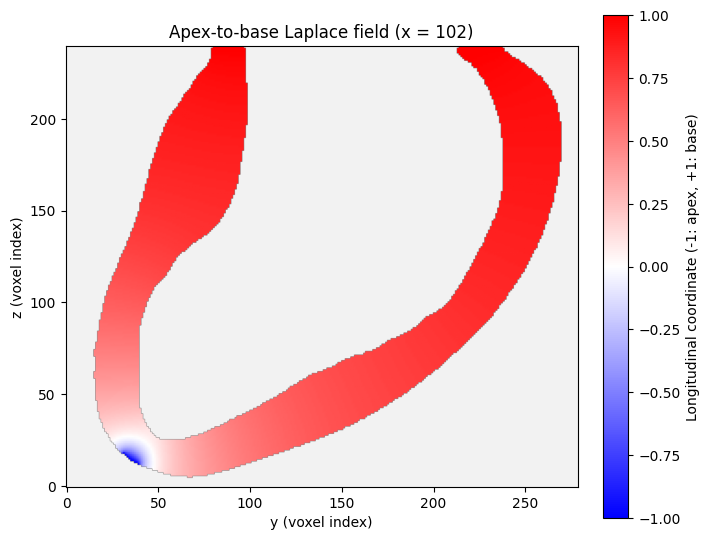

In [41]:
import matplotlib.pyplot as plt
from finitewave_tools.linalg.linalg import make_system, linear_solver

apex_base_boundaries = [(apex_indices, -1), (base_indices, 1)]

K_apex_base, b_apex_base, x0, inds = make_system(K, dirichlet_conditions=apex_base_boundaries)

apex_base_laplace = x0
apex_base_laplace[inds] = linear_solver(K_apex_base, b_apex_base, x0=x0[inds])

apex_base_mesh = np.zeros_like(dilated_mesh, dtype=np.float64)
apex_base_mesh.flat[full_indices] = apex_base_laplace.astype(np.float64)

slice_x = apex_center[0]
field_slice = np.ma.masked_where(
    ~dilated_mesh[slice_x].T, apex_base_mesh[slice_x].T
)
fig, ax = plt.subplots(figsize=(7, 6), constrained_layout=True)
im = ax.imshow(field_slice, cmap="bwr", origin="lower", vmin=-1, vmax=1)
ax.set(title=f"Apex-to-base Laplace field (x = {slice_x})",
       xlabel="y (voxel index)", ylabel="z (voxel index)")
ax.set_facecolor("#f2f2f2")
fig.colorbar(im, ax=ax, label="Longitudinal coordinate (-1: apex, +1: base)", shrink=0.85)
plt.show()


### Endo to Epi Laplace Field

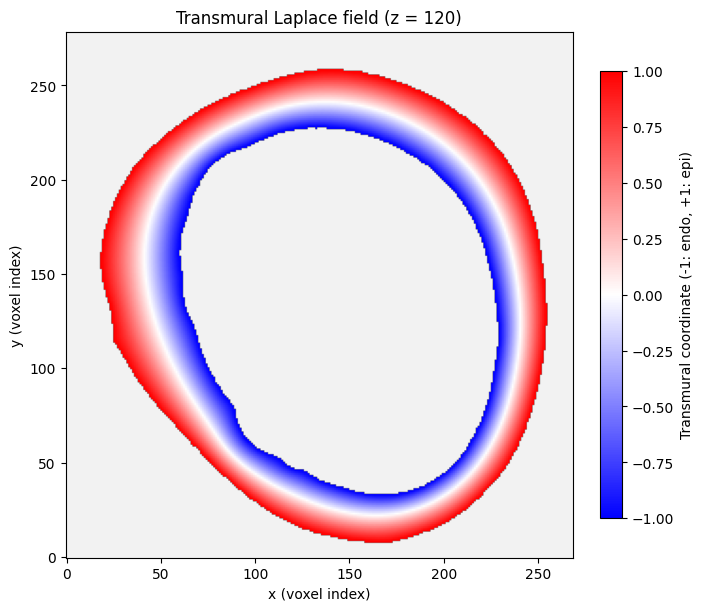

In [50]:
endo_epi_boundaries = [(endo_indices, -1), (epi_indices, 1)]

K_endo_epi, b_endo_epi, x0, inds = make_system(K, dirichlet_conditions=endo_epi_boundaries)

endo_epi_laplace = x0
endo_epi_laplace[inds] = linear_solver(K_endo_epi, b_endo_epi, x0=x0[inds])
endo_epi_mesh = np.zeros_like(dilated_mesh, dtype=np.float64)
endo_epi_mesh.flat[full_indices] = endo_epi_laplace.astype(np.float64)

slice_z = endo_epi_mesh.shape[2] // 2
field_slice = np.ma.masked_where(
    ~dilated_mesh[:, :, slice_z].T, endo_epi_mesh[:, :, slice_z].T
)
fig, ax = plt.subplots(figsize=(7, 6), constrained_layout=True)
im = ax.imshow(field_slice, cmap="bwr", origin="lower", vmin=-1, vmax=1)
ax.set(title=f"Transmural Laplace field (z = {slice_z})",
       xlabel="x (voxel index)", ylabel="y (voxel index)")
ax.set_facecolor("#f2f2f2")
fig.colorbar(im, ax=ax, label="Transmural coordinate (-1: endo, +1: epi)", shrink=0.85)
plt.show()


## Compute local directions

Normalize the field gradients inside the original tissue. Rescale the transmural field to [0, 1] and sample points by layer for visualization.

Each gradient points toward increasing field values: toward the base for the longitudinal field and toward the epicardium for the transmural field. Normalization keeps only direction. Sampling reduces the number of arrows shown; the full set of tissue gradients is retained for fiber construction.

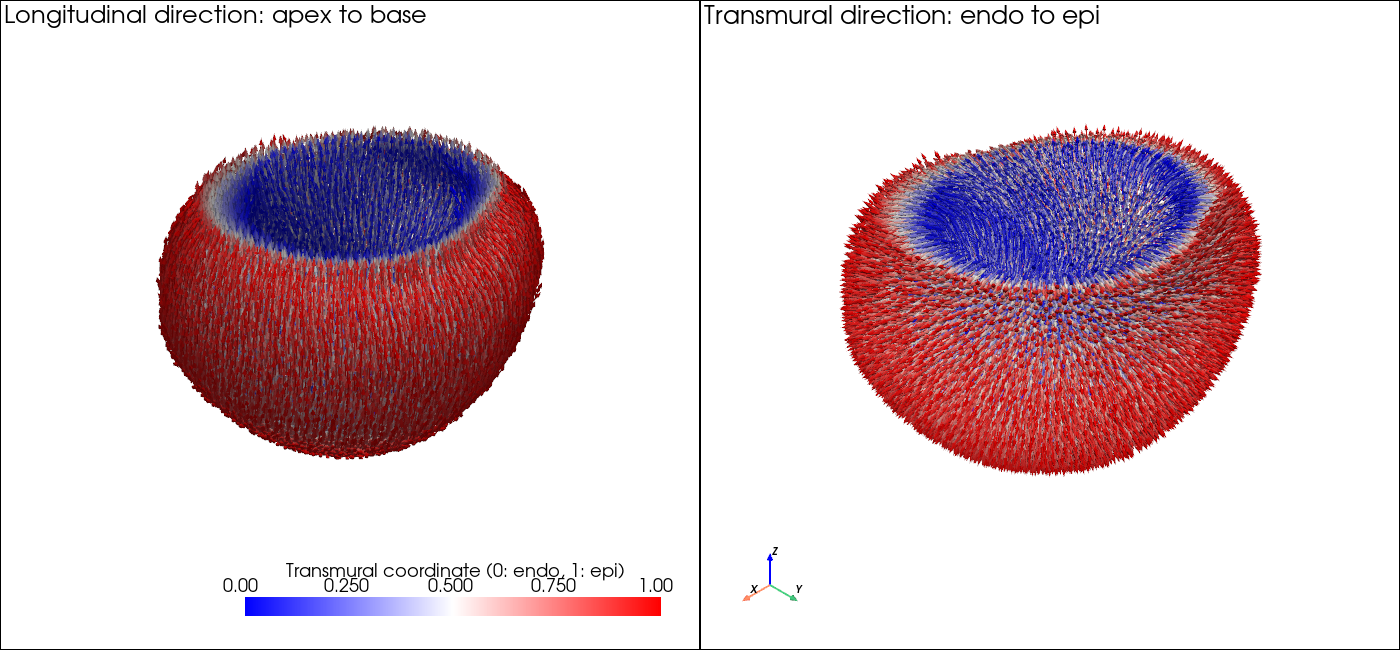

In [ ]:
from finitewave_tools.fibers.fdm.gradient import compute_gradient, normalize_vectors
from finitewave_tools.fibers.fdm.sampling import sample_from_layers


def build_arrows(coords, vectors, colors, scale_factor=5, colors_name="Colors"):
    """Create uniformly sized arrow glyphs with a scalar color field.

    Parameters
    ----------
    coords : ndarray, shape (N, 3)
        Arrow origins in voxel-index coordinates.
    vectors : ndarray, shape (N, 3)
        Arrow directions, normally unit vectors.
    colors : ndarray, shape (N,)
        Scalar values attached to the arrows for coloring.
    scale_factor : float, optional
        Uniform glyph size in voxel units. Defaults to 5.
    colors_name : str, optional
        Name of the scalar array used for plotting. Defaults to "Colors".

    Returns
    -------
    pyvista.PolyData
        Arrow geometry carrying the named scalar array. Vector magnitudes
        do not change glyph size.
    """
    mesh = pv.PolyData(coords.astype(np.float64))
    mesh.point_data["Vectors"] = vectors
    mesh.point_data[colors_name] = colors

    arrows = mesh.glyph(
        orient="Vectors", 
        scale=False,  
        factor=scale_factor
    )
    return arrows


apex_base_grad = compute_gradient(apex_base_mesh, normalize=True, mask=mesh > 0)
endo_epi_grad = compute_gradient(endo_epi_mesh, normalize=True, mask=mesh > 0)

coords = np.argwhere(mesh > 0)
N_LAYERS = 10
endo_epi_dist = endo_epi_mesh[mesh > 0]
endo_epi_dist = ((endo_epi_dist - endo_epi_dist.min()) / 
                 (endo_epi_dist.max() - endo_epi_dist.min()))
endo_epi_layers = np.digitize(endo_epi_dist, bins=np.linspace(0, 1, N_LAYERS + 1))

sampled_ids = sample_from_layers(endo_epi_layers, coords, 5)
selected_coords = coords[sampled_ids]
endo_epi_vec = endo_epi_grad[sampled_ids]
apex_base_vec = apex_base_grad[sampled_ids]
colors = endo_epi_dist[sampled_ids]

pv.set_jupyter_backend("static")
pl = pv.Plotter(shape=(1, 2), window_size=(1400, 650))
pl.set_background("white")
pl.subplot(0, 0)
pl.add_text("Longitudinal direction: apex to base", font_size=14, color="black")
pl.add_mesh(build_arrows(selected_coords, apex_base_vec, colors, scale_factor=15,
                         colors_name="Transmural coordinate"), 
            scalars="Transmural coordinate", cmap="bwr", clim=(0, 1),
            scalar_bar_args={"title": "Transmural coordinate (0: endo, 1: epi)",
                             "color": "black"}, label="Longitudinal")
pl.subplot(0, 1)
pl.add_text("Transmural direction: endo to epi", font_size=14, color="black")
pl.add_mesh(build_arrows(selected_coords, endo_epi_vec, colors, scale_factor=15,
                         colors_name="Transmural coordinate"),
            scalars="Transmural coordinate", cmap="bwr", clim=(0, 1),
            scalar_bar_args={"title": "Transmural coordinate (0: endo, 1: epi)",
                             "color": "black"}, label="Transmural")
pl.link_views()
pl.show_axes()
pl.reset_camera()
pl.show()

## Build the local basis

Keep the longitudinal direction, make the transmural direction orthogonal to it, and obtain the circumferential direction by a cross product.

The two gradients need not be perpendicular. Orthogonalization removes the longitudinal component from the transmural vector, and the cross product completes a right-handed orthonormal basis. The resulting vectors are longitudinal (`e0`), transmural (`e1`), and circumferential (`e2`).

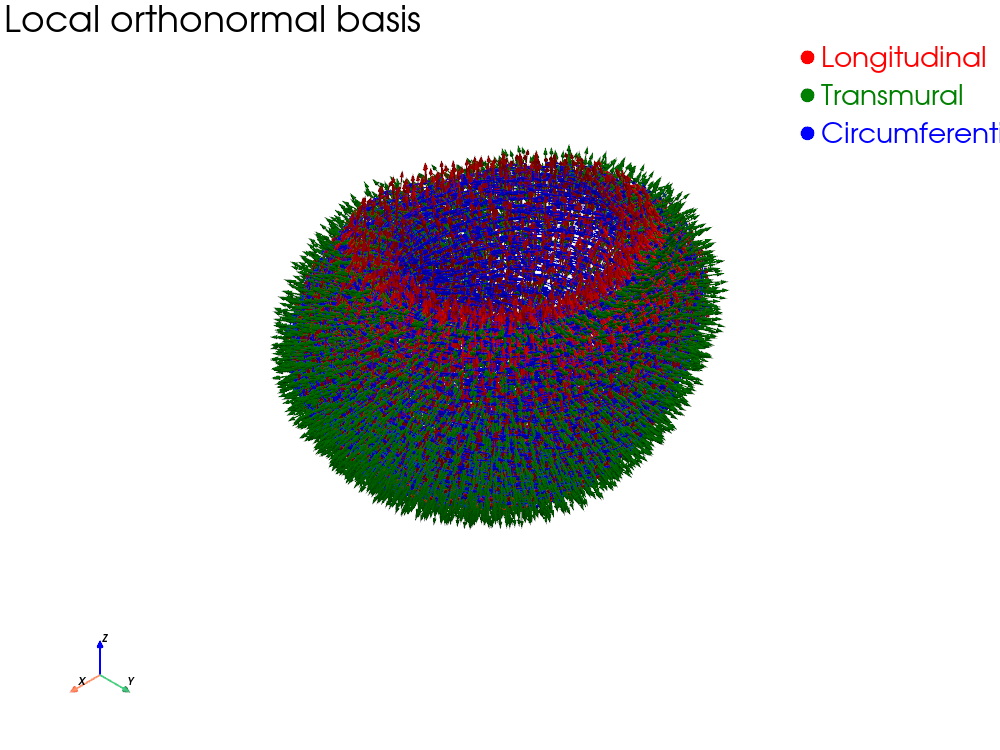

In [48]:
from finitewave_tools.fibers.fdm.coordinate_system import (
    build_coord_system
)
e0, e1, e2 = build_coord_system(apex_base_grad, endo_epi_grad)

sampled_ids = sample_from_layers(endo_epi_layers, coords, 10)
selected_coords = coords[sampled_ids]

e0_vec = e0[sampled_ids]
e1_vec = e1[sampled_ids]
e2_vec = e2[sampled_ids]

pv.set_jupyter_backend("static")
pl = pv.Plotter(window_size=(1000, 750))
pl.set_background("white")
pl.add_text("Local orthonormal basis", font_size=16, color="black")
pl.add_arrows(selected_coords, e0_vec, mag=15, color="red", label="Longitudinal")
pl.add_arrows(selected_coords, e1_vec, mag=15, color="green", label="Transmural")
pl.add_arrows(selected_coords, e2_vec, mag=15, color="blue", label="Circumferential")
pl.add_legend(bcolor="white", face="circle", size=(0.25, 0.16))
pl.view_isometric()
pl.enable_parallel_projection()
pl.show_axes()
pl.reset_camera()
pl.show()

## Generate fibers

Vary the fiber angle linearly from -60 degrees at the endocardium to +60 degrees at the epicardium, using the basis defined above. Pass angles in radians and set the out-of-plane tilt to zero. Color the sampled fibers by their angle.

The angle is measured from the circumferential axis toward the longitudinal axis. With zero tilt, each fiber lies in the local longitudinal–circumferential plane; at the midpoint of the rescaled transmural field, the angle is zero and the fiber follows the circumferential direction. The output `fibers` contains one unit vector per tissue voxel, in the same order as `coords`; only a subset is displayed.

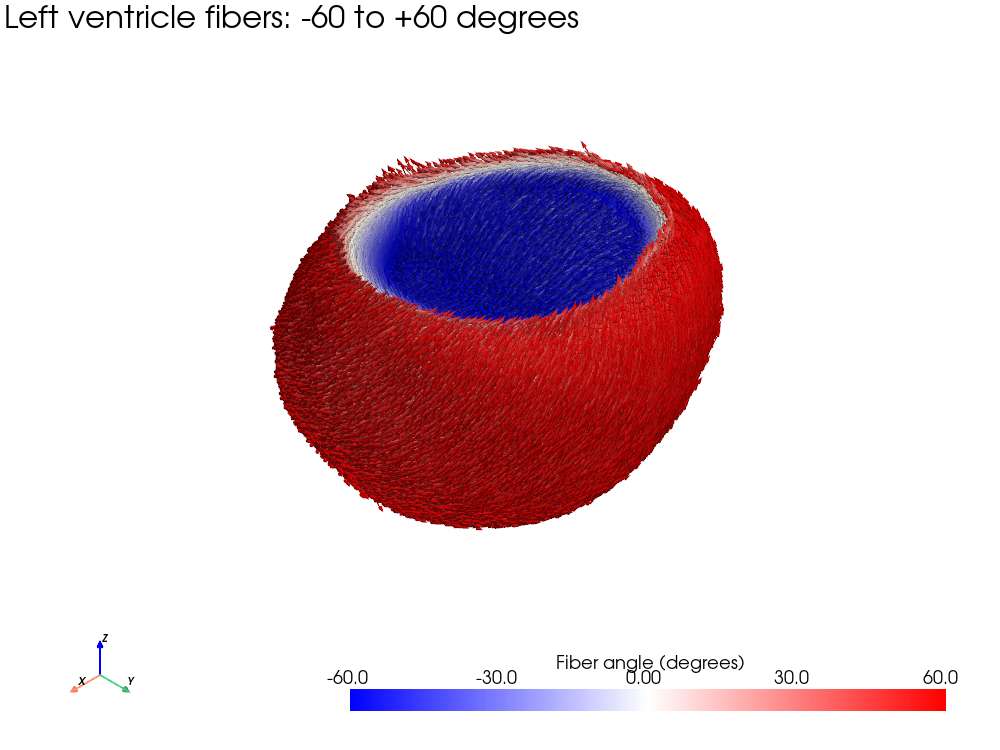

In [56]:
from finitewave_tools.fibers.rule_based_fibers import (
    rule_based_fibers,
    fiber_angles
)

alpha = fiber_angles(endo_epi_dist, alpha_endo=-60, alpha_epi=60)
beta = np.zeros_like(alpha)

fibers = rule_based_fibers(e0, e1, e2, alpha, beta)

endo_epi_layers = np.digitize(endo_epi_dist, bins=np.linspace(0, 1, N_LAYERS + 1))
sampled_ids = sample_from_layers(endo_epi_layers, coords, 3)

selected_coords = coords[sampled_ids]
colors = np.degrees(alpha[sampled_ids])

fiber_arrows = build_arrows(selected_coords, fibers[sampled_ids], colors, scale_factor=15, colors_name="Alpha")

pv.set_jupyter_backend("static")
pl = pv.Plotter(window_size=(1000, 750))
pl.set_background("white")
pl.add_text("Left ventricle fibers: -60 to +60 degrees", font_size=16, color="black")
pl.add_mesh(fiber_arrows, scalars="Alpha", cmap="bwr", clim=(-60, 60),
            scalar_bar_args={"title": "Fiber angle (degrees)", "color": "black", "n_labels": 5})
pl.view_isometric()
pl.enable_parallel_projection()
pl.show_axes()
pl.reset_camera()
pl.show()